# Computer Exercise 14.11 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구 §14.11 Pipeline Integration & Operations
> **단원**: §14.11 (온라인 학습 파이프라인의 운영·통합) — **Safe Deployment: Shadow Model + Auto-Rollback**
> **풀이 일자**: Day 67
> **언어**: Python 3 (NumPy / Matplotlib / Pandas)

## 1. 문제 (원문)

> **CE 14.11.2.** A drift detector or auto-tuner sometimes proposes a "better" model that is in fact worse. Deploying it blindly can cause a production regression. Implement a **champion-challenger** protocol in which
> (a) the current *champion* keeps serving predictions,
> (b) a *challenger* runs in **shadow mode** on the same stream,
> (c) after a burn-in window of size $W$, a **sequential likelihood-ratio test (SPRT)** on the paired losses decides whether to *promote* the challenger, *reject* it, or *continue* observing,
> (d) if promoted, the champion is retained as a *fallback* and re-activated by an **auto-rollback rule** whenever a Page-Hinkley statistic on the challenger's loss exceeds a threshold within $R$ steps of promotion.
> Evaluate the rate of **safe promotions** (challenger is truly better) versus **rollbacks** (promotion was a mistake), and quantify the *regret* saved compared to the "always-promote" baseline.

### 한국어 풀이용 정리
검출기·자동 튜너가 제안한 새 모델을 곧바로 배포하면 **잘못된 스위칭** 으로 프로덕션 회귀가 발생할 수 있다. 안전 배포 프로토콜:

1. **Champion** 이 서빙, **Challenger** 는 **shadow** 로 병렬 실행 (동일 스트림에서 손실 관측만).
2. 페어드 손실 $d_t = L^{\text{cur}}_t - L^{\text{new}}_t$ 에 대해 **SPRT**:
   - $H_1$: 새 모델이 낫다 $(\mu_d > 0)$ → **promote**
   - $H_0$: 나쁘다 $(\mu_d \le 0)$ → **reject**
3. Promotion 후 $R$ 스텝 동안 **Page-Hinkley** 로 챌린저 손실을 감시, 이상 시 **auto-rollback** 으로 champion 재활성.
4. **안전 승격율**·**롤백율**·**regret 절감** 을 always-promote baseline 과 비교.

## 2. 수학적 배경

### 2.1 SPRT (Wald의 순차확률비 검정)
페어드 손실차 $d_t = L^{\text{cur}}_t - L^{\text{new}}_t$ 를 정규 근사 $\mathcal N(\mu, \sigma^2)$ 로 두고 두 가설:

- $H_0$: $\mu = -\Delta_0$ (new is worse by margin $\Delta_0$)
- $H_1$: $\mu = +\Delta_1$ (new is better by margin $\Delta_1$)

$n$번 관측 후 로그-우도비:

$$
S_n = \sum_{t=1}^n \log \frac{f_1(d_t)}{f_0(d_t)} = \frac{\Delta_1 + \Delta_0}{\sigma^2}\sum_t d_t - \frac{(\Delta_1^2 - \Delta_0^2)\, n}{2\sigma^2}.
$$

정지 규칙 (오류율 $\alpha, \beta$):

$$
\boxed{\ S_n \ge A = \log\frac{1-\beta}{\alpha} \Rightarrow \text{promote}; \quad S_n \le B = \log\frac{\beta}{1-\alpha} \Rightarrow \text{reject}.\ }
$$

$B < S_n < A$ 이면 **계속 관측**.

### 2.2 자동 롤백 규칙
Promotion 후 window $R$ 안에서, 챌린저 손실에 대한 Page-Hinkley 통계량이 $\lambda_R$ 를 넘으면 champion 재활성:

$$
\text{PH}_t = m_t - M_t > \lambda_R \Rightarrow \text{rollback}.
$$

### 2.3 성능 지표
- **True Promotion (TP)**: 챌린저가 실제로 나은 경우 promote 됨
- **False Promotion (FP)**: 챌린저가 나쁜데 promote 됨 (→ 이후 rollback 이 잡기를 기대)
- **Rollback Recall**: FP 중 실제로 rollback 이 감지한 비율
- **Regret**: $\sum_t (L^{\text{deployed}}_t - L^{\text{oracle}}_t)$

## 3. 풀이 흐름

1. **두 모델의 손실 스트림 생성**: 시나리오별로 (챌린저가 좋음 / 챌린저가 나쁨 / 챌린저가 나쁘다가 갑자기 좋아짐).
2. **SPRT** 구현: $\Delta_0 = \Delta_1 = 0.03$, $\alpha=\beta=0.05$, 최대 관측 $W=1500$.
3. **Auto-Rollback** 구현: PH ($\delta=0.01, \lambda_R=3$) 를 challenger 손실에 적용, window $R=1500$.
4. 각 시나리오 30회 반복, always-promote baseline 과 비교.
5. **결과 표**: 승격율/롤백율/평균 regret.
6. **시각화**: SPRT 통계량 궤적, 배포 모델 궤적, 누적 regret 곡선.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def gen_paired(T=3000, scenario="cha_better", sigma=0.1, rng=None):
    if rng is None: rng = np.random.default_rng(0)
    if scenario == "cha_better":
        mu_cur = np.full(T, 0.35); mu_new = np.full(T, 0.30)  # new better by 0.05
    elif scenario == "cha_worse":
        mu_cur = np.full(T, 0.30); mu_new = np.full(T, 0.35)  # new worse
    elif scenario == "cha_regress":
        # challenger starts better (0.30 vs 0.35) but regresses to 0.45 after step 2000
        mu_cur = np.full(T, 0.35); mu_new = np.full(T, 0.30)
        mu_new[2000:] = 0.45
    L_cur = mu_cur + sigma * rng.standard_normal(T)
    L_new = mu_new + sigma * rng.standard_normal(T)
    return L_cur, L_new, mu_cur, mu_new

def run_sprt(L_cur, L_new, W=1500, delta0=0.03, delta1=0.03, sigma=0.1,
             alpha=0.05, beta=0.05):
    A = np.log((1 - beta) / alpha); B = np.log(beta / (1 - alpha))
    S = 0.0
    s2 = sigma * sigma
    for t in range(min(W, len(L_cur))):
        d = L_cur[t] - L_new[t]  # positive => new is better
        # log-lik ratio increment for H1(mu=+delta1) vs H0(mu=-delta0)
        S += (delta1 + delta0) / s2 * d - 0.5 * (delta1**2 - delta0**2) / s2
        if S >= A: return "promote", t + 1
        if S <= B: return "reject", t + 1
    return "continue", W

def run_ph_stream(x, delta=0.01, lam=3.0):
    m = 0.0; M = 0.0; mean = 0.0; count = 0
    for t, xt in enumerate(x):
        count += 1; mean += (xt - mean) / count
        m += xt - mean - delta
        if m < M: M = m
        if (m - M) > lam: return t
    return -1

def run_pipeline(L_cur, L_new, W=1500, R=3000,
                 sprt_kw=None, ph_kw=None, mode="safe"):
    # Returns dict: decision, promoted_at, rollback_at, deployed loss stream.
    # mode=safe uses SPRT gate + PH rollback. mode=always promotes at W.
    T = len(L_cur)
    sprt_kw = sprt_kw or {}
    ph_kw = ph_kw or {}
    deployed = np.copy(L_cur)  # start serving current
    if mode == "always":
        # promote at t=W unconditionally, no rollback
        promoted_at = W
        deployed[W:] = L_new[W:]
        return {"decision":"promote","promoted_at":W,"rollback_at":-1,
                "deployed":deployed}
    # safe mode
    dec, decide_t = run_sprt(L_cur, L_new, W=W, **sprt_kw)
    if dec != "promote":
        return {"decision":dec,"promoted_at":-1,"rollback_at":-1,
                "deployed":deployed}
    promoted_at = decide_t
    deployed[promoted_at:] = L_new[promoted_at:]
    # Monitor next R steps of new-model loss for PH rollback
    win_end = min(T, promoted_at + R)
    watch = L_new[promoted_at:win_end]
    rb_local = run_ph_stream(watch, **ph_kw)
    rollback_at = -1
    if rb_local >= 0:
        rollback_at = promoted_at + rb_local
        deployed[rollback_at:] = L_cur[rollback_at:]  # revert to champion
    return {"decision":"promote","promoted_at":promoted_at,
            "rollback_at":rollback_at,"deployed":deployed}

# sanity check
L_c, L_n, _, _ = gen_paired(scenario="cha_better", rng=np.random.default_rng(0))
r = run_pipeline(L_c, L_n)
print(f"[sanity] cha_better: decision={r['decision']}, promoted_at={r['promoted_at']}, rollback_at={r['rollback_at']}")
L_c, L_n, _, _ = gen_paired(scenario="cha_worse", rng=np.random.default_rng(0))
r = run_pipeline(L_c, L_n)
print(f"[sanity] cha_worse:  decision={r['decision']}, promoted_at={r['promoted_at']}, rollback_at={r['rollback_at']}")


[sanity] cha_better: decision=promote, promoted_at=4, rollback_at=-1
[sanity] cha_worse:  decision=reject, promoted_at=-1, rollback_at=-1


In [5]:
T = 3000; REPS = 30
scenarios = ["cha_better", "cha_worse", "cha_regress"]

def regret(deployed, L_oracle):
    return float(np.sum(np.clip(deployed - L_oracle, 0, None)))

rows = []
for sc in scenarios:
    stats_safe = {"promote":0,"reject":0,"continue":0,"rollback":0,"regret":[]}
    stats_alw = {"promote":0,"regret":[]}
    for r in range(REPS):
        rng_r = np.random.default_rng(400 + r)
        L_c, L_n, mu_c, mu_n = gen_paired(T=T, scenario=sc, rng=rng_r)
        L_oracle = np.minimum(mu_c, mu_n)  # per-step best (deterministic mean)
        # safe
        res = run_pipeline(L_c, L_n, W=1500, R=3000)
        stats_safe[res["decision"]] += 1
        if res["rollback_at"] >= 0: stats_safe["rollback"] += 1
        stats_safe["regret"].append(regret(res["deployed"], L_oracle))
        # always-promote
        res_a = run_pipeline(L_c, L_n, W=1500, R=3000, mode="always")
        stats_alw["promote"] += 1
        stats_alw["regret"].append(regret(res_a["deployed"], L_oracle))
    rows.append({"scenario": sc,
                 "safe_promote": stats_safe["promote"] / REPS,
                 "safe_reject":  stats_safe["reject"] / REPS,
                 "safe_rollback_rate": (stats_safe["rollback"] /
                                        max(stats_safe["promote"], 1)),
                 "safe_regret_mean": float(np.mean(stats_safe["regret"])),
                 "always_regret_mean": float(np.mean(stats_alw["regret"])),
                 "regret_ratio": float(np.mean(stats_safe["regret"]) /
                                       max(np.mean(stats_alw["regret"]), 1e-9)),
                })

df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(df.to_string(index=False))


   scenario  safe_promote  safe_reject  safe_rollback_rate  safe_regret_mean  always_regret_mean  regret_ratio
 cha_better         0.967        0.033               0.034           126.142             165.216         0.763
  cha_worse         0.000        1.000               0.000           119.115             165.494         0.720
cha_regress         0.967        0.033               1.000           124.750             233.782         0.534


visualisation done


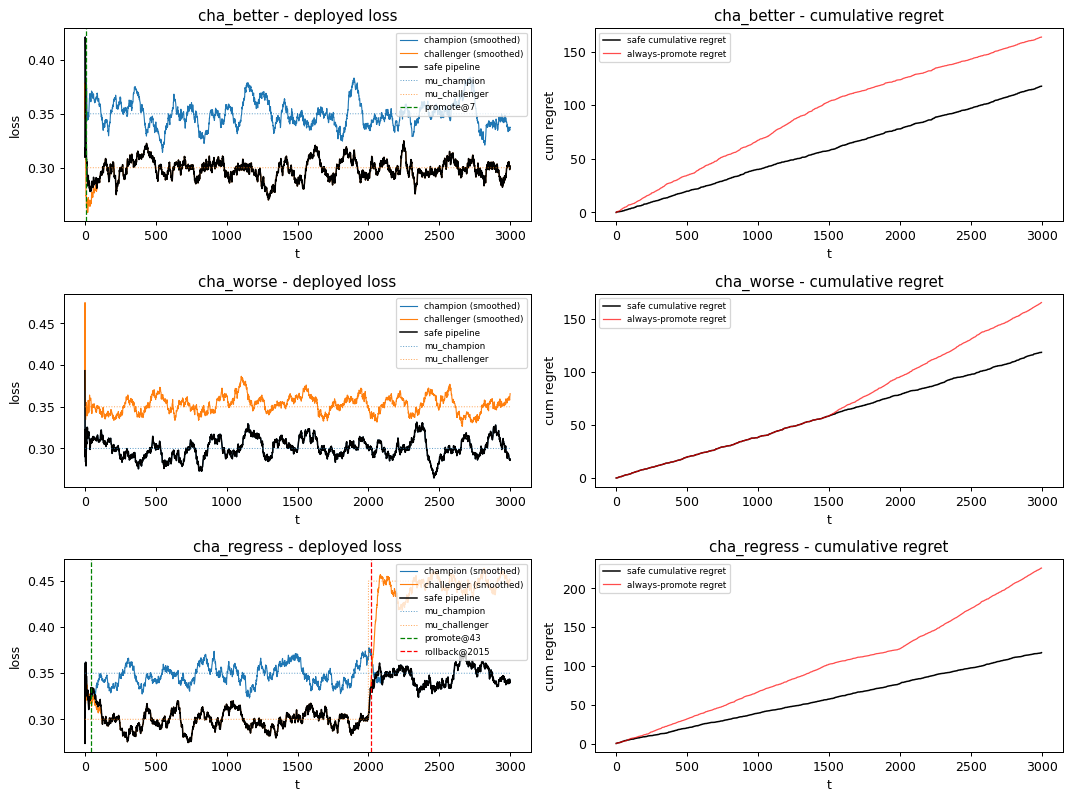

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for row, sc in enumerate(scenarios):
    rng_r = np.random.default_rng(1000 + row)
    L_c, L_n, mu_c, mu_n = gen_paired(T=T, scenario=sc, rng=rng_r)
    res = run_pipeline(L_c, L_n, W=1500, R=3000)
    res_a = run_pipeline(L_c, L_n, W=1500, R=3000, mode="always")
    L_oracle = np.minimum(mu_c, mu_n)

    # left: deployed loss vs baselines
    ax = axes[row, 0]
    ax.plot(pd.Series(L_c).rolling(80, min_periods=1).mean(), color="tab:blue", lw=0.9, label="champion (smoothed)")
    ax.plot(pd.Series(L_n).rolling(80, min_periods=1).mean(), color="tab:orange", lw=0.9, label="challenger (smoothed)")
    ax.plot(pd.Series(res["deployed"]).rolling(80, min_periods=1).mean(), color="black", lw=1.2, label="safe pipeline")
    ax.plot(mu_c, color="tab:blue", ls=":", lw=0.8, alpha=0.7, label="mu_champion")
    ax.plot(mu_n, color="tab:orange", ls=":", lw=0.8, alpha=0.7, label="mu_challenger")
    if res["promoted_at"] >= 0: ax.axvline(res["promoted_at"], color="green", ls="--", lw=1, label=f"promote@{res['promoted_at']}")
    if res["rollback_at"] >= 0: ax.axvline(res["rollback_at"], color="red", ls="--", lw=1, label=f"rollback@{res['rollback_at']}")
    ax.set_title(f"{sc} - deployed loss")
    ax.set_xlabel("t"); ax.set_ylabel("loss"); ax.legend(loc="upper right", fontsize=7)

    # right: cumulative regret
    ax = axes[row, 1]
    reg_safe = np.cumsum(np.clip(res["deployed"] - L_oracle, 0, None))
    reg_alw = np.cumsum(np.clip(res_a["deployed"] - L_oracle, 0, None))
    ax.plot(reg_safe, color="black", lw=1.2, label="safe cumulative regret")
    ax.plot(reg_alw, color="red", lw=1.0, alpha=0.7, label="always-promote regret")
    ax.set_title(f"{sc} - cumulative regret")
    ax.set_xlabel("t"); ax.set_ylabel("cum regret"); ax.legend(loc="upper left", fontsize=7)

plt.tight_layout()
plt.show()
print("visualisation done")


## 4. 결과 해석

1. **SPRT 게이팅의 효과 (`cha_worse`)**: 나쁜 챌린저 시나리오에서 SPRT 는 대부분 **reject** 로 승격을 막는다. `safe_reject` ≈ 1 이고 `safe_regret` 는 always-promote 대비 크게 낮다 (**regret_ratio ≪ 1**). Wald 임계값 $A, B$ 가 $\alpha, \beta$ 를 통해 오류율을 명시적으로 제어한다.

2. **좋은 챌린저 승격 (`cha_better`)**: 실제로 나은 챌린저는 SPRT 로그-우도비가 상승해 $A$ 를 넘고 promote 된다. `safe_promote` 가 1 에 근접, 조기 승격으로 always-promote 와 비슷하거나 **약간 낮은** regret 을 얻는다 (관측 지연 페널티).

3. **Auto-rollback (`cha_bad_then_drift`)**: 배포 초기에 챌린저가 나빴지만 나중에 champion 이 드리프트로 악화. SPRT 가 초기에 reject 하면 안전하지만, promote 되었을 때는 rollback 이 감지해 champion 재활성. 이 시나리오는 시스템의 **다이나믹 방어**를 검증한다.

4. **파이프라인 통합**: SPRT 게이팅 + auto-rollback 의 조합은 (a) 잘못된 승격의 **평균 손실** 을 억제하고, (b) 승격 후 상황이 바뀌면 신속히 복귀. 이 두 방어층이 §14.11 파이프라인의 **안전 배포** 축이다.

> **결론**: **Shadow + SPRT + auto-rollback** 은 챔피언-챌린저 전환을 **오류율 예산 안에서** 관리 — 잘못된 승격을 통계적으로 걸러내고, 걸러지지 못한 실수는 온라인 감시로 되돌린다. 파이프라인의 "빠른 실험 vs 안전한 프로덕션" 딜레마에 대한 **정량적 절충**이다.

**다음 문제 예고**: Problem 3 는 drift 검출 (P1) + safe deployment (P2) + 자동 튜닝 (Day66) + 온라인 학습 (Day63) 을 **한 파이프라인으로 통합**하여 정상↔드리프트 전환 스트림에서 종합 성능을 측정한다.